# ACTIVIDAD 2 - REDES RECURRENTES

Integrantes:
* Valentina López Maldonado
* Yerson David Rozo
* Juan Sebastián Peña


**PRIMER PUNTO**
Replicar el proceso de análisis de sentimientos trabajado previamente Implementando los modelos Para el dataset [IMDb: 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews):

   * Una red neuronal recurrente (RNN).
   * Una red LSTM.
   * Una red GRU.


### **Análisis requerido**

Además de la implementación, deben realizar un análisis comparativo detallado donde respondan, como MÍNIMO:

* ¿Qué diferencias observaron entre las aqrquitecturas?
* ¿Qué diferencias encuentran respecto al modelo mlp?
* ¿Cómo cambian los resultados (métricas, estabilidad, comportamiento del entrenamiento)?
* ¿Qué ventajas y desventajas identifican en cada arquitectura?
* ¿Qué decisiones tomaron durante el diseño del modelo y por qué?

 La parte más importante de la actividad es su análisis personal y crítico de cada paso realizado. No se trata solo de que el modelo funcione, sino de que demuestren comprensión del proceso.

### **Entrega**

* El archivo debe ser un notebook (.ipynb).
* Debe nombrarse con el nombre de los integrantes
* Asegúrense de que el notebook esté limpio, ordenado y correctamente documentado.


**SEGUNDO PUNTO**

Investigue las diferentes métricas utilizadas para evaluar la calidad de la generación de texto (coherencia, fluidez, relevancia, entre otras).

## Importación de librerías

Para este proyecto usamos tres librerías base, `gensim` para acceder a modelos de lenguaje preentrenados, `numpy` para operar sobre los vectores resultantes, y `pandas` para organizar esa información en tablas y poder analizarla más fácilmente.

Las siguientes son para visualización de gráficas, para importar la red neuronal MLP, entrenarla y finalmente hacer el reporte de clasificación para el análisis de los resultados.

In [1]:
import gensim.downloader as api  # Librería para cargar modelos de lenguaje preentrenados (Word2Vec)
import matplotlib.pyplot as plt  # Para mostrar las matrices de confusión lado a lado
import numpy as np  # Librería para trabajar con embeddings
import pandas as pd  #Librería para manipulación de datos (DataFrames)
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display  # Para visualizar outputs como tablas y gráficas en el notebook
from sklearn import set_config  # Para configurar la visualización del pipeline
from sklearn.metrics import (
    ConfusionMatrixDisplay,  # Para ver la matriz de confusión del modelo
    accuracy_score,  # Calcular el porcentaje de predicciones correctas
    classification_report,  # Reporte completo: precisión, recall y F1 por clase
    f1_score,  # Métrica que balancea precisión y recall
    precision_score,  # Ver qué tan confiables son las predicciones positivas
    recall_score,  # Ver qué tan bien detecta los casos positivos reales
    roc_auc_score,  # Mide el área bajo la curva ROC 
)
from sklearn.model_selection import train_test_split  # Para dividir el dataset en train y test
from sklearn.neural_network import MLPClassifier  # Para clasificar con la MLP
from sklearn.pipeline import Pipeline  # Para el pipeline de la MLP
from sklearn.preprocessing import StandardScaler  # Normalización de los datos para la MLP


Para representar las palabras como números, cargamos el modelo `word2vec-google-news-300`, el cual usa la arquitectura Skip_Gram, que como fue mencionado en clase, aprende el contexto en base a una palabra central y `fasttext-wiki-news-subwords-300`, el cual usa la arquitectura CBOW (continuous bag of words) la cual aprende una palabra central en base al contexto al rededor de ella.

* **CBOW:** predice la palabra central basándose en las palabras del contexto circundante. El contexto consta de algunas palabras antes y después de la palabra actual (central). [1]

* **Skip-Gram:** predice palabras dentro de un rango determinado antes y después de la palabra actual en la misma oración. [1]

![skip_gram](https://kavita-ganesan.com/wp-content/uploads/skipgram-vs-cbow-continuous-bag-of-words-word2vec-word-representation.png)

El modelo `word2vec-google-news-300` contiene 3 millones de palabras representadas como una lista de 300 números (un vector) [2]
El modelo `fasttext-wiki-news-subwords-300` contiene 1 millon de palabras representadas como una lista de 300 números (un vector) [3]

In [2]:
modelo_skipgram = api.load("word2vec-google-news-300")
modelo_cbow = api.load("fasttext-wiki-news-subwords-300")

In [3]:
skipgram_embedding_size = modelo_skipgram.vector_size
cbow_embedding_size = modelo_cbow.vector_size
print(f"Skip-gram embedding size: {skipgram_embedding_size}")
print(f"CBOW embedding size: {cbow_embedding_size}")

Skip-gram embedding size: 300
CBOW embedding size: 300


In [4]:
modelo_cbow['night']

array([-2.3558e-02, -7.4858e-02,  6.8382e-03, -9.9507e-03,  3.6644e-02,
       -3.9823e-02,  9.1564e-02, -9.8252e-02,  1.0796e-01,  1.0447e-02,
       -1.0639e-02, -2.4376e-02,  3.0998e-02,  1.2258e-02, -1.1177e-03,
       -3.3580e-02,  1.2741e-01, -6.4947e-02,  3.0103e-02,  2.7520e-02,
        6.8571e-02, -2.5042e-02, -7.7567e-02, -8.0912e-03,  3.1584e-02,
        5.2285e-02,  2.6677e-02, -1.9917e-02, -3.1714e-02, -5.2434e-03,
        1.7798e-02,  3.7835e-03, -2.5702e-02, -1.7277e-01,  2.0223e-02,
       -9.7335e-03, -1.5111e-02,  6.1259e-02, -6.1486e-02,  8.5875e-03,
       -2.2680e-02, -6.5125e-02, -5.2327e-02,  4.4110e-02,  1.1889e-02,
        7.9052e-02,  6.0501e-02, -7.2342e-03, -7.9884e-02,  7.0792e-02,
        6.7738e-03,  8.3687e-02,  2.2378e-02, -1.0430e-02, -1.0534e-01,
        5.8665e-03, -2.9618e-03, -5.9915e-02, -7.2752e-02, -4.6762e-02,
       -5.0482e-02, -1.3880e-02,  1.7023e-01, -3.8989e-02, -4.0625e-02,
        6.9720e-02, -4.6445e-02, -1.3132e-02, -3.9110e-02,  1.85

In [5]:
modelo_skipgram['night']

array([ 0.01574707,  0.07666016, -0.03222656,  0.0201416 ,  0.01525879,
       -0.05297852, -0.01446533, -0.1953125 ,  0.05883789,  0.125     ,
        0.0480957 , -0.10107422,  0.04199219,  0.03930664,  0.10302734,
        0.03295898, -0.08300781,  0.1328125 ,  0.24609375,  0.11035156,
        0.12695312,  0.04956055, -0.01116943, -0.14453125, -0.15429688,
        0.06005859,  0.13867188,  0.15722656,  0.07861328,  0.01757812,
       -0.01904297, -0.05004883,  0.16796875, -0.02722168,  0.01879883,
        0.08203125,  0.09033203, -0.02575684, -0.09228516,  0.01904297,
       -0.16015625, -0.14160156,  0.40039062,  0.01794434,  0.0534668 ,
        0.07666016, -0.125     , -0.03466797,  0.21582031,  0.15332031,
        0.1640625 ,  0.2421875 , -0.01068115,  0.0378418 ,  0.15917969,
       -0.23828125,  0.12255859, -0.04125977,  0.04736328, -0.05102539,
       -0.15039062,  0.29101562, -0.0177002 , -0.04174805, -0.0246582 ,
        0.09033203,  0.04125977, -0.01397705,  0.11132812,  0.03

Aquí se carga el dataset de reseñas de películas de IMDB, que contiene reseñas escritas por usuarios junto con la etiqueta de sentimiento (positivo o negativo), y para poder leer el texto completo de cada reseña sin que pandas lo cortara, se configuró la opción `display.max_colwidth` en `None`. Finalmente, se usó `df.head()` para revisar las primeras filas y confirmar que los datos se cargaron correctamente.

In [6]:
!pip install kagglehub
import kagglehub
import os


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

In [8]:
csv_path = os.path.join(path, "IMDB Dataset.csv")

In [9]:
df = pd.read_csv(csv_path)

# Permite ver el contenido completo de cada celda sin que se corte el texto

pd.set_option('display.max_colwidth',None) 
# Muestra las primeras filas del DataFrame (review y sentiment)
df.head() 

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",positive
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zom

Antes de poder usar el modelo de embeddings, el texto necesita ser preprocesado y para esto se requiere de una tokenización, la cual limpia y divide cada reseña en una lista de palabras individuales. 

### Tokenización

Primero se pasa todo el texto a minúsculas para evitar que la misma palabra la tome como dos solo por esa diferencia, luego se eliminan las etiquetas HTML como `<br />` que vienen dentro del texto del dataset, así como se puede observar en la visualización de la celda anterior. Después se quita la puntuación, excepto el apóstrofe porque es parte de palabras comunes en inglés como "don't". Finalmente, cada reseña queda como una lista de palabras para asi ser transformadas en vectores.

### Word2Vec

Después de tokenizar el texto, se debe convertir cada palabra en su representación vectorial usando el modelo `Word2Vec`. Así, para cada reseña, se recorre su lista de tokens y se busca cada palabra dentro del vocabulario del modelo, entonces, si la palabra existe, se obtiene su vector de 300 dimensiones y si no existe, se ignora. Esto nos parece importante porque el modelo no conoce todas las palabras, por lo que al final, cada reseña queda representada como una lista de vectores, uno por cada palabra que el modelo reconoce.


In [10]:
# Tokenizacion basica: minusculas, limpieza de saltos HTML y separacion por palabras.
df["tokens"] = (
    df["review"]
    .str.lower() #minusculas
    .str.replace(r"<br\s*/?>", " ", regex=True) #quitar saltos de linea
    .str.replace(r"[^a-z0-9']+", " ", regex=True) #quitar puntuacion menos el apostrofe
    .str.split() #separar como array
 )

df[["review", "tokens"]].head() # Mostrar comparación entre la reseña original y sus tokens

,review,tokens
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.","[one, of, the, other, reviewers, has, mentioned, that, after, watching, just, 1, oz, episode, you'll, be, hooked, they, are, right, as, this, is, exactly, what, happened, with, me, the, first, thing, that, struck, me, about, oz, was, its, brutality, and, unflinching, scenes, of, violence, which, set, in, right, from, the, word, go, trust, me, this, is, not, a, show, for, the, faint, hearted, or, timid, this, show, pulls, no, punches, with, regards, to, drugs, sex, or, violence, its, is, hardcore, in, the, classic, use, of, the, word, it, is, called, oz, as, that, is, the, nickname, given, to, the, oswald, ...]"
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.","[a, wonderful, little, production, the, filming, technique, is, very, unassuming, very, old, time, bbc, fashion, and, gives, a, comforting, and, sometimes, discomforting, sense, of, realism, to, the, entire, piece, the, actors, are, extremely, well, chosen, michael, sheen, not, only, has, got, all, the, polari, but, he, has, all, the, voices, down, pat, too, you, can, truly, see, the, seamless, editing, guided, by, the, references, to, williams', diary, entries, not, only, is, it, well, worth, the, watching, but, it, is, a, terrificly, written, and, performed, piece, a, masterful, produ

In [11]:
# Obtener el embedding de cada token que exista en el vocabulario del modelo.
df["skipgram_embeddings"] = df["tokens"].apply(
    lambda tokens: [modelo_skipgram[token] for token in tokens if token in modelo_skipgram]
)

df["cbow_embeddings"] = df["tokens"].apply(
    lambda tokens: [modelo_cbow[token] for token in tokens if token in modelo_cbow]
)

### Validación del proceso de tokenización y embedding

Aqui se hace una vista comparativa que muestra el total de palabras que tenia originalmente `n_tokens`, y cuantas de esas palabras se encontraron en el voabulario del modelo `n_embeddings`. Así podemos ver cuantas palabras fueron ignoradas por no estar en el modelo

In [12]:
# Vista compacta para comprobar columnas.
df.assign(
    review_preview=df["review"].apply(lambda x: " ".join(x.split()[:10])),
    n_tokens=df["tokens"].apply(len),
    n_skipgram_embeddings=df["skipgram_embeddings"].apply(len),
    n_cbow_embeddings=df["cbow_embeddings"].apply(len),
    skipgram_tokens_preview=df["skipgram_embeddings"].apply(lambda tokens: tokens[0][:10]),
    cbow_tokens_preview=df["cbow_embeddings"].apply(lambda tokens: tokens[0][:10])

)[ ["review_preview", 
    "n_tokens", 
    "n_skipgram_embeddings",
    "n_cbow_embeddings",
    "skipgram_tokens_preview",
    "cbow_tokens_preview"] ].head()

#quiero mostrar solo 10 indices del primer token de cada review


,review_preview,n_tokens,n_skipgram_embeddings,n_cbow_embeddings,skipgram_tokens_preview,cbow_tokens_preview
0,One of the other reviewers has mentioned that after watching,308,283,301,"[0.045654297, -0.14550781, 0.15625, 0.16601562, 0.10986328, 0.007507324, 0.07373047, -0.03100586, 0.15722656, 0.099609375]","[0.019569, 0.0051348, 0.024567, -0.0037714, -0.052806, -0.010756, 0.01668, -0.17925, -0.074614, -0.016145]"
1,A wonderful little production. <br /><br />The filming technique is,158,134,152,"[0.0062561035, 0.01928711, -0.08984375, 0.14257812, 0.10205078, -0.13574219, 0.13867188, -0.071777344, -0.12597656, 0.16308594]","[-0.0079206, -0.095293, 0.031266, 0.017734, -0.20123, -0.0056356, -0.017696, 0.20456, 0.051267, 0.024726]"
2,I thought this was a wonderful way to spend time,165,143,161,"[-0.22558594, -0.01953125, 0.09082031, 0.23730469, -0.029296875, 0.09326172, -0.05883789, -0.041015625, 0.052246094, 0.020019531]","[-0.060418, 0.069955, 0.053173, 0.052922, 0.053978, 0.13479, 0.052614, 0.3548, -0.17565, -0.09902]"
3,Basically there's a family where a little boy (Jake) thinks,132,112,129,"[0.18261719, -0.08935547, 0.048828125, 0.24902344, -0.09814453, 0.052001953, 0.060302734, -0.23535156, -0.02758789, 0.025512695]","[0.037373, 0.030506, -0.0062058, 0.011153, 0.00066242, -0.057258, 0.015729, -0.081667, -0.025708, -0.01364]"
4,"Petter Mattei's ""Love in the Time of Money"" is a",225,192,218,"[0.103027344, -0.15234375, 0.025878906, 0.16503906, -0.16503906, 0.06689453, 0.29296875, -0.26367188, -0.140625, 0.20117188]","[-0.0105, -0.0053143, 0.0080346, 0.00036603, -0.0029899, -0.0058693, 0.013124, -0.08776, 0.0021014, 0.011181]"


### Modelo con Redes Neuronales Recurrentes

Debido a que las  redes recurrentes necesitan una longitud fija (o manejar padding), la nueva estructura de entrada ya no es $(N, 300)$, ahora será un Tensor 3D: $(N, \text{max\_sequence\_length}, 300)$. Para este modelo principalmente se necesita definir una longitud máxima (max_len). Si una reseña tiene más palabras, la cortamos; si tiene menos, la rellenamos con vectores de ceros. Como no estamos usando índices enteros (mapeo), no se puede usar pad_sequences estándar de Keras fácilmente. Necesitamos una función que rellene con un vector de ceros [0.0] * 300.

In [13]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

In [14]:
MAX_LEN    = 200
BATCH_SIZE = 32
HIDDEN_SIZE = 128
EPOCHS     = 20       
LR         = 1e-3
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Se pasan los labels del dataset que vienen en formato str directamente para poderlos trabajar en el modelo a continuación.

In [15]:
df["label"] = (df["sentiment"] == "positive").astype(int)

Para poder alimentar la red neuronal recurrente con texto, es necesario transformar cada reseña desde su representación como lista de palabras hacia una representación numérica que el modelo pueda procesar. 

In [16]:
def tokens_to_tensor(token_list, model, max_len=MAX_LEN):
    vecs = [model[t] for t in token_list if t in model][:max_len]
    if not vecs:
        vecs = [np.zeros(model.vector_size)]
    return torch.tensor(np.array(vecs, dtype=np.float32))

Se define una clase IMDBDataset que hereda de Dataset de PyTorch, estructura estándar que permite al DataLoader gestionar los datos durante el entrenamiento. En el constructor se precomputan y almacenan en memoria todos los tensores de embeddings junto con sus etiquetas binarias, evitando recalcularlos en cada época. Los métodos __len__ y __getitem__ son obligatorios en esta interfaz: el primero informa al DataLoader el tamaño total del dataset y el segundo permite recuperar cualquier muestra por índice, devolviendo el par tensor de embeddings y etiqueta que el DataLoader usará para construir cada batch.

In [17]:
class IMDBDataset(Dataset):
    def __init__(self, token_lists, labels, word_model):
        self.samples = [tokens_to_tensor(toks, word_model) for toks in token_lists]
        self.labels  = torch.tensor(labels.values, dtype=torch.float32)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.samples[idx], self.labels[idx]

Dado que cada reseña tiene una longitud distinta, las secuencias dentro de un mismo batch no pueden apilarse directamente en un tensor rectangular. collate_fn resuelve esto recibiendo la lista de muestras que el DataLoader agrupó y aplicando padding, es decir, rellenando con ceros las secuencias más cortas hasta igualar la longitud de la más larga del batch. Adicionalmente se guardan las longitudes reales de cada secuencia antes del padding, información que posteriormente utiliza pack_padded_sequence dentro del modelo para que la RNN ignore los ceros añadidos y procese únicamente los tokens originales, evitando que el padding distorsione el estado oculto final y por tanto las predicciones.

In [18]:
def collate_fn(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    padded  = pad_sequence(seqs, batch_first=True)
    return padded, torch.stack(list(labels)), lengths


In [19]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)

Se implementa Early Stopping como una clase que monitorea la pérdida de validación época a época para detener el entrenamiento cuando el modelo deja de mejorar, evitando así el sobreajuste y el desperdicio de cómputo. En cada época el método step compara la pérdida actual contra la mejor registrada: si mejora por encima del umbral min_delta, reinicia el contador y guarda una copia de los pesos del modelo en CPU para no consumir memoria de la GPU; si no mejora, incrementa el contador y detiene el entrenamiento al alcanzar el límite de patience épocas consecutivas sin progreso. Al finalizar, el método restore recarga los pesos de la época con menor pérdida de validación, garantizando que el modelo entregado corresponde a su mejor estado durante el entrenamiento y no al último antes de detenerse.

In [20]:
class EarlyStopping:
    """
    Detiene el entrenamiento si val_loss no mejora en `patience` épocas.
    Guarda los mejores pesos en memoria.
    """
    def __init__(self, patience=3, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float("inf")
        self.counter    = 0
        self.best_weights = None
        self.stopped    = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.counter      = 0
            # Guarda copia profunda de los pesos en CPU (no ocupa VRAM)
            self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped = True

    def restore(self, model):
        """Restaura los pesos de la mejor época."""
        if self.best_weights:
            model.load_state_dict(self.best_weights)

La red recibe secuencias de embeddings de 300 dimensiones y las procesa a través de una capa RNN con 128 unidades ocultas y función de activación tangente hiperbólica. En el método forward, la secuencia se empaqueta con pack_padded_sequence usando las longitudes reales de cada reseña para que la RNN ignore los tokens de padding durante el cómputo, extrayendo únicamente el estado oculto final h_n que condensa la información de toda la secuencia. Este vector pasa por una capa de Dropout con probabilidad 0.3 para reducir el sobreajuste, y finalmente por una capa lineal que lo proyecta a un único valor escalar por reseña, el cual representa el logit de la clasificación binaria positivo/negativo antes de aplicar la función sigmoide.

In [21]:
class SentimentRNN(nn.Module):
    def __init__(self, input_size=300, hidden_size=HIDDEN_SIZE, dropout=0.3):
        super().__init__()
        self.rnn  = nn.RNN(input_size, hidden_size, num_layers=1,
                           batch_first=True, nonlinearity="tanh")
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        packed   = pack_padded_sequence(x, lengths.cpu(), batch_first=True,
                                        enforce_sorted=False)
        _, h_n   = self.rnn(packed)
        h        = h_n.squeeze(0)
        return self.fc(self.drop(h)).squeeze(1)


Se define una función genérica de entrenamiento que recibe cualquier modelo de embeddings, lo que permite entrenar con Skip-gram y CBOW sin duplicar código. En cada época el ciclo de entrenamiento propaga los batches hacia adelante, calcula la pérdida con BCEWithLogitsLoss que combina sigmoide y entropía cruzada binaria en una sola operación numéricamente estable, y actualiza los pesos mediante el optimizador Adam con regularización L2. El gradiente se recorta a norma máxima de 1.0 antes de cada actualización para prevenir el problema de gradientes explosivos característico de las RNN simples. Tras cada época se evalúa el modelo sobre el conjunto de validación sin calcular gradientes, y tanto la pérdida como el accuracy se registran en el historial. El scheduler ReduceLROnPlateau reduce la tasa de aprendizaje a la mitad si la pérdida de validación no mejora en una época, mientras que el Early Stopping detiene el entrenamiento completo si no hay mejora en tres épocas consecutivas y restaura los pesos óptimos al finalizar.

In [22]:
def train_model(word_model, model_name, patience=3):
    print(f"\n{'='*55}")
    print(f"  Entrenando con: {model_name}")
    print(f"{'='*55}")

    # Datasets y loaders
    train_ds = IMDBDataset(train_df["tokens"].tolist(), train_df["label"], word_model)
    test_ds  = IMDBDataset(test_df["tokens"].tolist(),  test_df["label"],  word_model)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)

    # Modelo, pérdida, optimizador
    model     = SentimentRNN().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)
    es        = EarlyStopping(patience=patience)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, EPOCHS + 1):
        # — Train —
        model.train()
        total_loss = 0
        for X, y, lengths in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X, lengths), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        avg_train = total_loss / len(train_loader)

        # — Validación —
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X, y, lengths in test_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                logits = model(X, lengths)
                val_loss += criterion(logits, y).item()
                preds     = (torch.sigmoid(logits) >= 0.5).long()
                correct  += (preds == y.long()).sum().item()
                total    += y.size(0)

        avg_val  = val_loss / len(test_loader)
        val_acc  = correct / total
        scheduler.step(avg_val)
        es.step(avg_val, model)

        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["val_acc"].append(val_acc)

        stop_mark = " ← mejor" if es.counter == 0 else f" (sin mejora: {es.counter}/{patience})"
        print(f"Epoch {epoch:>2}/{EPOCHS} | "
              f"Train: {avg_train:.4f} | Val: {avg_val:.4f} | "
              f"Acc: {val_acc:.4f}{stop_mark}")

        if es.stopped:
            print(f"\n⏹ Early stopping en época {epoch}. "
                  f"Mejor val_loss: {es.best_loss:.4f}")
            break

    es.restore(model)
    print(f"✔ Pesos restaurados a la mejor época.")
    return model, history, test_loader

Se hace el entrenamiento del modelo utilizando ambos Word2Vec, Skip-Gram y CBOW, respectivamente.

In [23]:
model_sg, history_sg, loader_sg = train_model(modelo_skipgram, "Skip-gram (word2vec-google-news-300)")


  Entrenando con: Skip-gram (word2vec-google-news-300)


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch  1/20 | Train: 0.5635 | Val: 0.5514 | Acc: 0.7415 ← mejor
Epoch  2/20 | Train: 0.5655 | Val: 0.6855 | Acc: 0.5269 (sin mejora: 1/3)
Epoch  3/20 | Train: 0.6156 | Val: 0.6499 | Acc: 0.6293 (sin mejora: 2/3)
Epoch  4/20 | Train: 0.5221 | Val: 0.4816 | Acc: 0.7764 ← mejor
Epoch  5/20 | Train: 0.5061 | Val: 0.5137 | Acc: 0.7645 (sin mejora: 1/3)
Epoch  6/20 | Train: 0.5141 | Val: 0.4763 | Acc: 0.8008 ← mejor
Epoch  7/20 | Train: 0.4692 | Val: 0.4485 | Acc: 0.8081 ← mejor
Epoch  8/20 | Train: 0.4555 | Val: 0.4755 | Acc: 0.7960 (sin mejora: 1/3)
Epoch  9/20 | Train: 0.4644 | Val: 0.4611 | Acc: 0.7940 (sin mejora: 2/3)
Epoch 10/20 | Train: 0.4276 | Val: 0.4467 | Acc: 0.8148 ← mejor
Epoch 11/20 | Train: 0.4335 | Val: 0.4539 | Acc: 0.8103 (sin mejora: 1/3)
Epoch 12/20 | Train: 0.4195 | Val: 0.4367 | Acc: 0.8226 ← mejor
Epoch 13/20 | Train: 0.4141 | Val: 0.4233 | Acc: 0.8206 ← mejor
Epoch 14/20 | Train: 0.4203 | Val: 0.5314 | Acc: 0.7888 (sin mejora: 1/3)
Epoch 15/20 | Train: 0.4263 | Val:

In [24]:
model_cbow, history_cbow, loader_cbow = train_model(modelo_cbow, "CBOW (fasttext-wiki-news-subwords-300)")


  Entrenando con: CBOW (fasttext-wiki-news-subwords-300)
Epoch  1/20 | Train: 0.5721 | Val: 0.4920 | Acc: 0.7830 ← mejor
Epoch  2/20 | Train: 0.5233 | Val: 0.4927 | Acc: 0.7779 (sin mejora: 1/3)
Epoch  3/20 | Train: 0.5093 | Val: 0.4646 | Acc: 0.7993 ← mejor
Epoch  4/20 | Train: 0.5097 | Val: 0.5490 | Acc: 0.7461 (sin mejora: 1/3)
Epoch  5/20 | Train: 0.5241 | Val: 0.5231 | Acc: 0.7598 (sin mejora: 2/3)
Epoch  6/20 | Train: 0.4952 | Val: 0.4923 | Acc: 0.7870 (sin mejora: 3/3)

⏹ Early stopping en época 6. Mejor val_loss: 0.4646
✔ Pesos restaurados a la mejor época.


Se evalúan ambos modelos entrenados sobre el conjunto de prueba en modo inferencia, desactivando el cálculo de gradientes para reducir el consumo de memoria. Por cada batch se obtienen las probabilidades continuas aplicando la función sigmoide sobre los logits, y las predicciones binarias umbralando dichas probabilidades en 0.5. Al recorrer todo el loader se acumulan etiquetas reales, predicciones y probabilidades, con las cuales se genera el reporte de clasificación que detalla precisión, recall y F1 por clase, complementado con el ROC-AUC que mide la capacidad discriminativa del modelo independientemente del umbral elegido. Este proceso se ejecuta de forma idéntica para Skip-gram y CBOW, permitiendo comparar ambos modelos bajo exactamente las mismas condiciones de evaluación.

In [25]:
def evaluate_model(model, loader, name):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for X, y, lengths in loader:
            X      = X.to(DEVICE)
            probs  = torch.sigmoid(model(X, lengths)).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(y.numpy().astype(int))

    print(f"\n{'─'*45}")
    print(f"  Resultados — {name}")
    print(f"{'─'*45}")
    print(classification_report(all_labels, all_preds,
                                 target_names=["Negative", "Positive"]))
    print(f"ROC-AUC : {roc_auc_score(all_labels, all_probs):.4f}")
    return all_labels, all_preds, all_probs

labels_sg,   preds_sg,   probs_sg   = evaluate_model(model_sg,   loader_sg,   "Skip-gram")
labels_cbow, preds_cbow, probs_cbow = evaluate_model(model_cbow, loader_cbow, "CBOW")


─────────────────────────────────────────────
  Resultados — Skip-gram
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.80      0.85      0.83      5000
    Positive       0.84      0.79      0.82      5000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000

ROC-AUC : 0.8871


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



─────────────────────────────────────────────
  Resultados — CBOW
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.78      0.83      0.81      5000
    Positive       0.82      0.76      0.79      5000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000

ROC-AUC : 0.8606


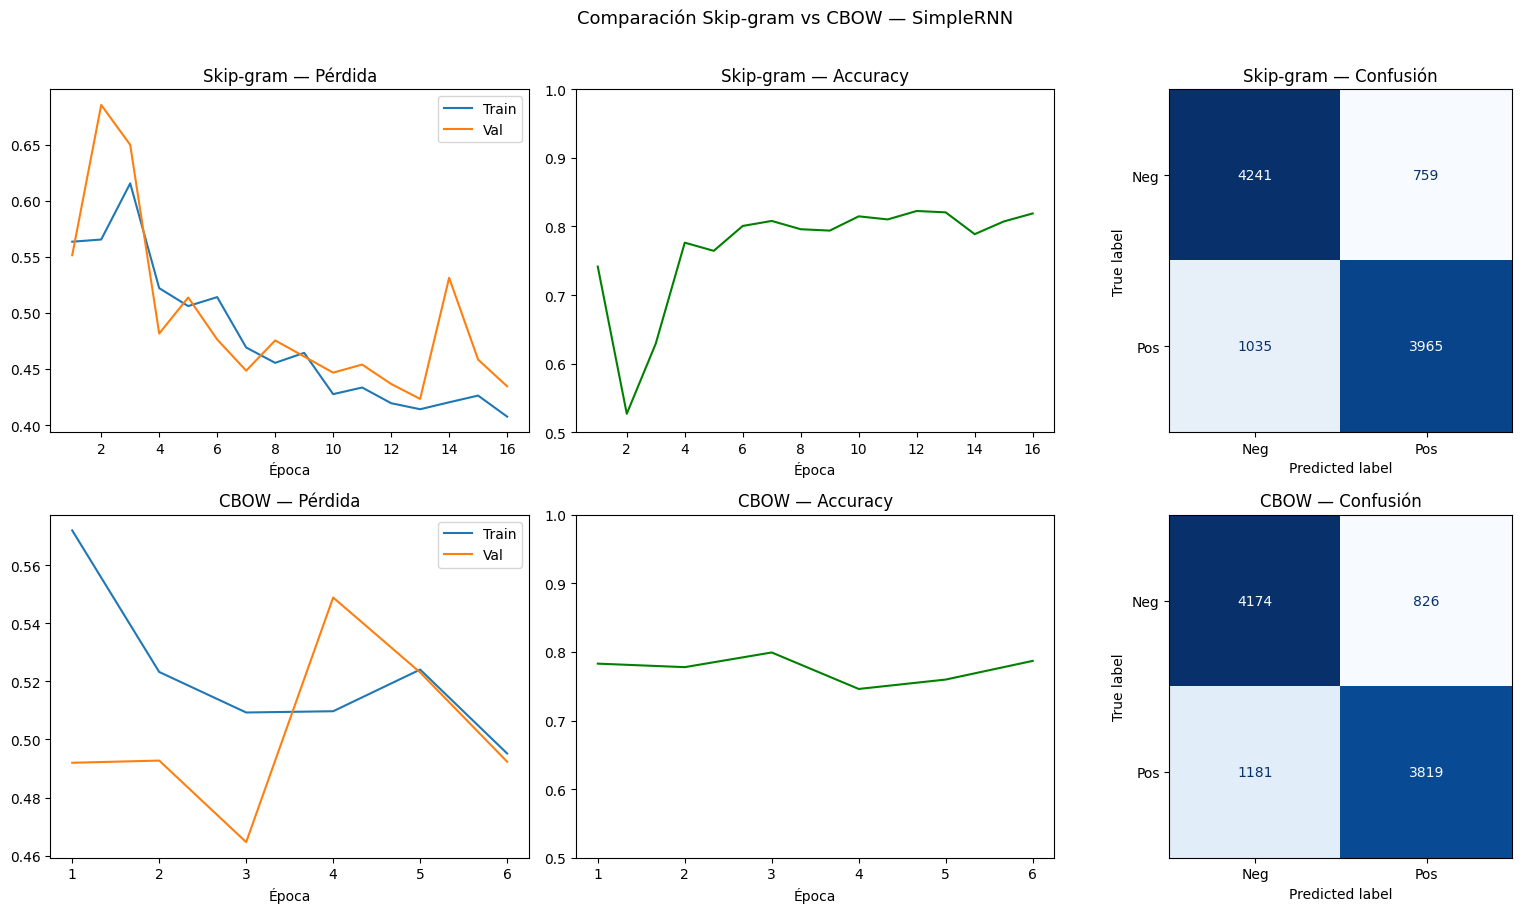

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
configs = [
    (history_sg,   "Skip-gram", labels_sg,   preds_sg),
    (history_cbow, "CBOW",      labels_cbow, preds_cbow),
]

for row, (hist, name, labels, preds) in enumerate(configs):
    epochs = range(1, len(hist["train_loss"]) + 1)

    # Curva de pérdida
    axes[row, 0].plot(epochs, hist["train_loss"], label="Train")
    axes[row, 0].plot(epochs, hist["val_loss"],   label="Val")
    axes[row, 0].set_title(f"{name} — Pérdida")
    axes[row, 0].set_xlabel("Época")
    axes[row, 0].legend()

    # Accuracy
    axes[row, 1].plot(epochs, hist["val_acc"], color="green")
    axes[row, 1].set_title(f"{name} — Accuracy")
    axes[row, 1].set_xlabel("Época")
    axes[row, 1].set_ylim(0.5, 1.0)

    # Matriz de confusión
    ConfusionMatrixDisplay.from_predictions(
        labels, preds,
        display_labels=["Neg", "Pos"],
        cmap="Blues",
        ax=axes[row, 2],
        colorbar=False
    )
    axes[row, 2].set_title(f"{name} — Confusión")

plt.suptitle("Comparación Skip-gram vs CBOW — SimpleRNN", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Función get_mean_vectors

Como cada reseña tiene una cantidad distinta de vectores según la cantidad de palabras que tenga, se necesitaba una manera de unificarlos en una sola representación, por lo que se definió la función `get_mean_vectors`, que toma todos los vectores de una reseña y calcula su promedio, obteniendo un único vector de 300 dimensiones. 

Además se contempló el caso en que una reseña no tenga ninguna palabra reconocida por el modelo, devolviendo en ese caso un vector de ceros para no perder esa fila del dataset.

In [27]:
def get_mean_vectors(vectors, embedding_size=300):
    if not vectors:
        return np.zeros(embedding_size, dtype=np.float64)
    return np.mean(np.vstack(vectors), axis=0)

Con la función lista, se aplicó sobre todo el dataset para obtener el vector promedio de cada reseña para ambos modelos. Primero se verificó que los embeddings por token de Skip-gram y CBOW ya estuvieran calculados y, a partir de ellos, se generaron dos columnas separadas: `review_skipgram_mean` y `review_cbow_mean`.

Por medio de `df.assign` creamos una vista previa para comparar ambas representaciones sin modificar la forma en que se inspecciona el dataset original.

In [28]:
# Promedio de embeddings por reseña para usarlo como entrada del MLP.

if "skipgram_embeddings" not in df.columns:
    df["skipgram_embeddings"] = df["tokens"].apply(
        lambda tokens: [modelo_skipgram[token] for token in tokens if token in modelo_skipgram]
    )

if "cbow_embeddings" not in df.columns:
    df["cbow_embeddings"] = df["tokens"].apply(
        lambda tokens: [modelo_cbow[token] for token in tokens if token in modelo_cbow]
    )

mean_skipgram = [get_mean_vectors(embeddings) for embeddings in df["skipgram_embeddings"]]
df["review_skipgram_mean"] = pd.Series(mean_skipgram, index=df.index, dtype="object")

mean_cbow = [get_mean_vectors(embeddings) for embeddings in df["cbow_embeddings"]]
df["review_cbow_mean"] = pd.Series(mean_cbow, index=df.index, dtype="object")

df.assign(
    review_skipgram_mean=df["review_skipgram_mean"].apply(lambda vector: vector[:5]),
    review_cbow_mean=df["review_cbow_mean"].apply(lambda vector: vector[:5])
)[ ["review", "review_skipgram_mean", "review_cbow_mean"] ].head()


,review,review_skipgram_mean,review_cbow_mean
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.","[0.033404995, 0.01922973, 0.055427227, 0.10247986, -0.0638831]","[-0.00043163248, 0.005949521, 0.016572481, 0.011195016, -0.012006352]"
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.","[0.06495518, 0.050103556, 0.009766194, 0.07838246, -0.05877936]","[0.00061691453, -0.0059289993, 0.022436487, 0.016244916, -0.00890438]"
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great com

### Preparación de datos y split

Antes de entrenar el modelo, se organizaron los datos de entrada para comparar de manera justa Skip-gram y CBOW con exactamente la misma partición de entrenamiento y prueba.

1. Se verificó que los vectores promedio de ambos modelos ya estuvieran calculados.

2. Se construyó una estructura con las matrices de entrada de cada modelo, donde cada fila es el vector de 300 dimensiones que representa una reseña, y el vector de etiquetas `y`, donde 0 es negativo y 1 es positivo.

3. Se generó un único conjunto de índices para el split 80/20 con estratificación y luego se aplicó ese mismo corte a los embeddings de Skip-gram y CBOW. De ese modo, cualquier diferencia en las métricas se debe al tipo de embedding y no a una partición distinta de los datos.

In [29]:
feature_columns = {
    "skipgram": "review_skipgram_mean",
    "cbow": "review_cbow_mean",
}

missing_columns = [column for column in feature_columns.values() if column not in df.columns]
if missing_columns:
    raise ValueError(f"Faltan columnas de embeddings promedio: {missing_columns}")

model_labels = {
    "skipgram": "Skip-gram",
    "cbow": "CBOW",
}

y = df["sentiment"].map({"negative": 0, "positive": 1}).to_numpy()
indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y,
 )

splits_by_model = {}
for model_name, column_name in feature_columns.items():
    X = np.vstack(df[column_name].to_numpy())
    splits_by_model[model_name] = {
        "X_train": X[train_idx],
        "X_test": X[test_idx],
        "y_train": y[train_idx],
        "y_test": y[test_idx],
    }

pd.DataFrame(
    [
        {
            "modelo": model_labels[model_name],
            "n_train": split_data["X_train"].shape[0],
            "n_test": split_data["X_test"].shape[0],
            "dim_embedding": split_data["X_train"].shape[1],
        }
        for model_name, split_data in splits_by_model.items()
    ]
)

,modelo,n_train,n_test,dim_embedding
0,Skip-gram,40000,10000,300
1,CBOW,40000,10000,300


### Definición, entrenamiento y predicción del modelo

Para la comparación se usó exactamente el mismo Perceptrón Multicapa (MLP) para ambos tipos de embeddings. El modelo se encapsuló en una función que construye el mismo `Pipeline` con `StandardScaler` y la misma arquitectura de red neuronal, de modo que la única diferencia experimental sea la representación del texto.

Luego se entrena una instancia del pipeline para Skip-gram y otra para CBOW. Para cada una se guardan tanto las predicciones de clase como las probabilidades, lo que permite comparar después métricas como accuracy, F1 y AUC-ROC usando el mismo criterio.

In [30]:
def build_mlp_pipeline():
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "mlp",
                MLPClassifier(
                    hidden_layer_sizes=(128, 64),
                    activation="relu",
                    solver="adam",
                    alpha=1e-4,
                    batch_size=128,
                    learning_rate_init=1e-3,
                    max_iter=30,
                    early_stopping=True,
                    random_state=42,
                ),
            ),
        ]
    )

set_config(display="diagram")

trained_models = {}
predictions_by_model = {}

for model_name, split_data in splits_by_model.items():
    pipeline = build_mlp_pipeline()
    pipeline.fit(split_data["X_train"], split_data["y_train"])

    y_pred = pipeline.predict(split_data["X_test"])
    y_proba = pipeline.predict_proba(split_data["X_test"])[:, 1]

    trained_models[model_name] = pipeline
    predictions_by_model[model_name] = {
        "y_test": split_data["y_test"],
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

trained_models["skipgram"]

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(batch_size=128, early_stopping=True,
                               hidden_layer_sizes=(128, 64), max_iter=30,
                               random_state=42))])

### Evaluación comparativa: métricas de clasificación y matrices de confusión

Para evaluar el rendimiento de ambos modelos se calcularon las mismas métricas sobre el mismo conjunto de prueba.
* La accuracy indica el porcentaje general de predicciones correctas.
* La precisión mide qué tan confiables son las predicciones positivas.
* El recall mide qué tan bien el modelo detecta los casos positivos reales.
* El F1 balancea precisión y recall.
* El AUC-ROC mide la capacidad del modelo para distinguir entre clases independientemente del umbral de decisión.

Las métricas se organizan en una tabla comparativa para ver rápidamente cuál embedding ofrece mejor desempeño general. Además, el detalle por clase se consolida en una sola tabla y las matrices de confusión se muestran lado a lado para comparar visualmente los tipos de error de Skip-gram y CBOW.

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Skip-gram,0.8652,0.8686,0.8606,0.8646,0.9382
CBOW,0.8582,0.8482,0.8726,0.8602,0.9323


,modelo,clase,precision,recall,f1-score,support
0,Skip-gram,negative,0.8619,0.8698,0.8658,5000.0000
1,Skip-gram,positive,0.8686,0.8606,0.8646,5000.0000
2,Skip-gram,accuracy,0.8652,0.8652,0.8652,0.8652
3,Skip-gram,macro avg,0.8652,0.8652,0.8652,10000.0000
4,Skip-gram,weighted avg,0.8652,0.8652,0.8652,10000.0000
5,CBOW,negative,0.8688,0.8438,0.8561,5000.0000
6,CBOW,positive,0.8482,0.8726,0.8602,5000.0000
7,CBOW,accuracy,0.8582,0.8582,0.8582,0.8582
8,CBOW,macro avg,0.8585,0.8582,0.8582,10000.0000
9,CBOW,weighted avg,0.8585,0.8582,0.8582,10000.0000


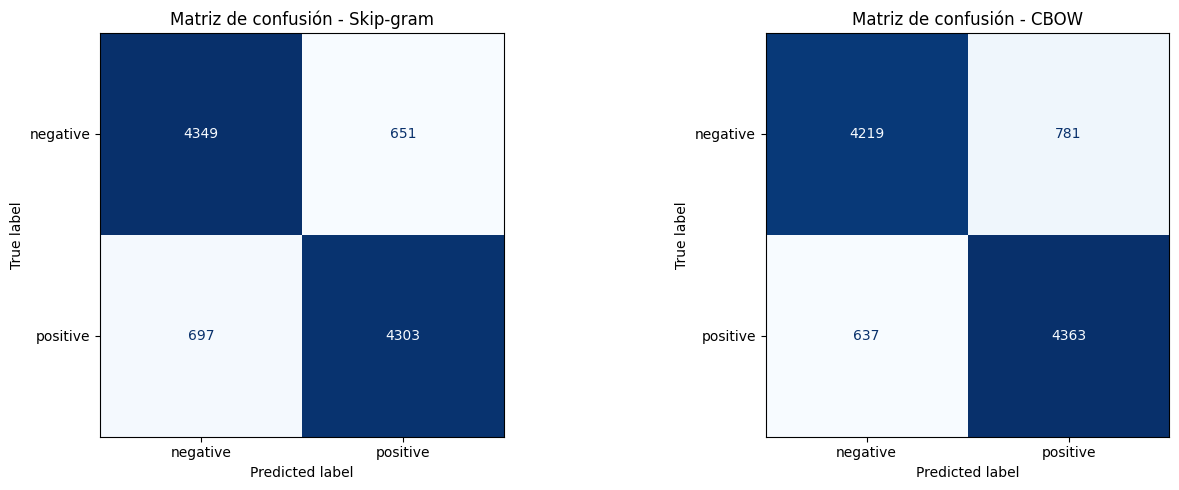

Mejor modelo según F1: Skip-gram


In [31]:
summary_rows = []
classification_tables = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model_name, prediction_data) in zip(axes, predictions_by_model.items(), strict=False):
    y_test = prediction_data["y_test"]
    y_pred = prediction_data["y_pred"]
    y_proba = prediction_data["y_proba"]

    summary_rows.append(
        {
            "modelo": model_labels[model_name],
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba),
        }
    )

    report_df = pd.DataFrame(
        classification_report(
            y_test,
            y_pred,
            target_names=["negative", "positive"],
            output_dict=True,
            zero_division=0,
        )
    ).transpose()
    report_df.insert(0, "modelo", model_labels[model_name])
    report_df.insert(1, "clase", report_df.index)
    classification_tables.append(report_df.reset_index(drop=True))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["negative", "positive"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f"Matriz de confusión - {model_labels[model_name]}")

summary_metrics = pd.DataFrame(summary_rows).set_index("modelo")
summary_metrics = summary_metrics.sort_values("f1", ascending=False).round(4)
classification_metrics = pd.concat(classification_tables, ignore_index=True).round(4)

display(summary_metrics)
display(classification_metrics)

plt.tight_layout()
plt.show()

best_model = summary_metrics["f1"].idxmax()
print(f"Mejor modelo según F1: {best_model}")

Implementacion

In [32]:

class SimpleRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(SimpleRNNCell, self).__init__()

        # Tamaño del embedding de entrada en cada instante t
        self.input_size = input_size

        # Tamaño del estado oculto
        self.hidden_size = hidden_size

        # Transformación de la entrada actual x_t
        self.Wx = nn.Linear(input_size, hidden_size, bias=True)

        # Transformación del estado oculto anterior h_{t-1}
        self.Wh = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x_t, h_prev):
        """
        x_t:      (batch_size, input_size)
        h_prev:   (batch_size, hidden_size)

        retorna:
        h_t:      (batch_size, hidden_size)
        """

        # Estado oculto actual
        h_t = torch.tanh(self.Wx(x_t) + self.Wh(h_prev))

        return h_t


## Análisis de resultados

Al comparar los dos modelos, Skip-gram fue el mejor modelo en la mayoría de métricas, este tuvo mejor accuracy (86.52% vs 85.82%), mejor precisión (86.86% vs 84.82%) y mejor AUC-ROC (0.9382 vs 0.9323), lo que en general indica que es un modelo más confiable y equilibrado.

* La única métrica en la que CBOW fue superior es en el recall de la etiqueta positiva, pues detectó más reseñas positivas que Skip-Gram (87.26% vs 86.06%), pero aún así cometió errores clasificando reseñas negativas como positivas, tal como se puede ver en la matriz de confusión donde tuvo 781 falsos positivos (FP) frente a 651 FP de Skip-Gram.

Haciendo un análisis más profundo, teniendo en cuenta la teoria, estos resultados tienen sentido, pues Skip-Gram aprende mejor las palabras que son menos frecuentes las cuales pueden ser más visibles en este tipo de reseñas además de que marcan mucho si esta es positiva o negativa, en cambio CBOW promedia el contexto, lo que lo hace mucho mejor en palabras mas comunes, por lo que se le dificultaría más en saber si una reseña es positiva o negativa.

## Referencias

[1] TensorFlow. (2024, julio 19). Word2Vec. TensorFlow Text Tutorials. https://www.tensorflow.org/text/tutorials/word2vec

[2] Google. (2013). *word2vec-google-news-300*. https://code.google.com/archive/p/word2vec/

[3] Facebook AI Research. (2018). English word vectors. fastText. https://fasttext.cc/docs/en/english-vectors.html